In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("house_price.csv")

In [3]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [4]:
df.shape

(545, 13)

In [5]:
df.drop_duplicates()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [6]:
df['mainroad'] = df['mainroad'].map({'yes':1,'no':0})

In [7]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,1,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,1,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,1,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,1,yes,yes,no,yes,2,no,furnished


In [8]:
df['guestroom'] = df['guestroom'].map({'yes':1,'no':0})

In [9]:
df['basement'] = df['basement'].map({'yes':1,'no':0})

In [10]:
df['hotwaterheating'] = df['hotwaterheating'].map({'yes':1,'no':0})

In [11]:
df['airconditioning'] = df['airconditioning'].map({'yes':1,'no':0})

In [12]:
df['prefarea'] = df['prefarea'].map({'yes':1,'no':0})

In [13]:
df['furnishingstatus'] = df['furnishingstatus'].map({'furnished':1,'unfurnished':-1, 'semi-furnished':0})

In [14]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [16]:
X=df[['furnishingstatus','area','bedrooms','bathrooms','stories','mainroad','guestroom','basement','hotwaterheating','airconditioning','parking','prefarea']]
Y = df['price']

In [17]:
X_train,X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.3,random_state=42)
model=LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [18]:
prediction = model.predict(X_test)

In [46]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient (Slope)': model.coef_
})

print(coefficients)
print(f"\nIntercept: {model.intercept_:,.2f}")

             Feature  Coefficient (Slope)
0   furnishingstatus         1.980313e+05
1               area         2.530623e+02
2           bedrooms         8.273487e+04
3          bathrooms         1.117373e+06
4            stories         4.158011e+05
5           mainroad         4.083205e+05
6          guestroom         2.795340e+05
7           basement         4.849802e+05
8    hotwaterheating         6.199343e+05
9    airconditioning         6.800069e+05
10           parking         3.040783e+05
11          prefarea         5.094415e+05

Intercept: -73,873.57


In [48]:
r2 = r2_score(Y_test, prediction)
r2

0.6435419628959109

In [50]:
rmse = np.sqrt(mean_squared_error(Y_test,prediction))
rmse

1238970.4429194625

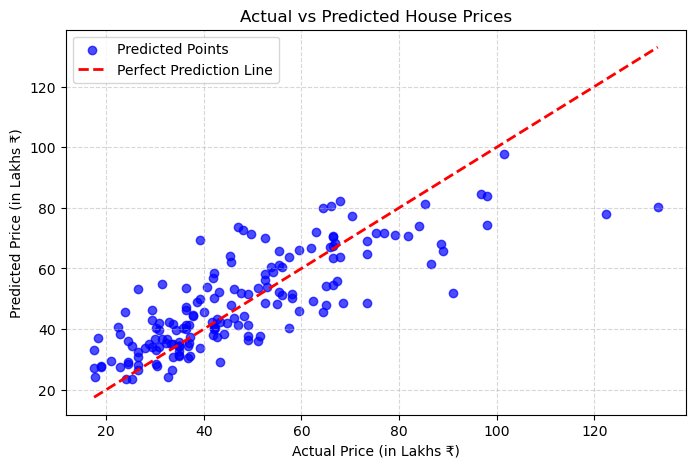

In [72]:
plt.figure(figsize=(8, 5))

plt.scatter(Y_test / 100000, predictions / 100000, color='blue', alpha=0.7, label='Predicted Points')

plt.plot([Y_test.min() / 100000, Y_test.max() / 100000], 
         [Y_test.min() / 100000, Y_test.max() / 100000], 
         color='red', linewidth=2, linestyle='--', label='Perfect Prediction Line')

plt.xlabel('Actual Price (in Lakhs ₹)')
plt.ylabel('Predicted Price (in Lakhs ₹)')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()